In [108]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/faizanhaider01/placement-modified/placement_modified.csv


In [109]:
df = pd.read_csv("/kaggle/input/datasets/faizanhaider01/placement-modified/placement_modified.csv")

In [110]:
df.sample(5)

,Unnamed: 0,cgpa,iq,placement
33,33,NaN,149.0,0
41,41,5.4,114.0,0
74,74,NaN,154.0,1
98,98,6.3,103.0,1
58,58,8.0,79.0,1


In [111]:
df = df.iloc[:,1:4]

In [112]:
df.sample(5)

,cgpa,iq,placement
71,6.1,132.0,1
18,4.0,100.0,0
39,4.6,146.0,0
30,7.6,128.0,1
28,5.2,90.0,0


In [113]:
df.isnull().mean()*100

cgpa         8.0
iq           7.0
placement    0.0
dtype: float64

In [114]:
X = df.drop(columns=['placement'])
y = df['placement']

In [115]:
from sklearn.model_selection import train_test_split

In [116]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [117]:
X_train.shape, X_test.shape

((80, 2), (20, 2))

In [118]:
X_train.isnull().mean()

cgpa    0.1000
iq      0.0625
dtype: float64

In [119]:
mean_cgpa = X_train['cgpa'].mean()
median_cgpa = X_train['cgpa'].median()

mean_iq = X_train['iq'].mean()
median_iq = X_train['iq'].median()

In [120]:
X_train['cgpa_median'] = X_train['cgpa'].fillna(median_cgpa)
X_train['cgpa_mean'] = X_train['cgpa'].fillna(mean_cgpa)

X_train['iq_median'] = X_train['iq'].fillna(median_iq)
X_train['iq_mean'] = X_train['iq'].fillna(mean_iq)

In [121]:
X_train.sample(5)

,cgpa,iq,cgpa_median,cgpa_mean,iq_median,iq_mean
20,6.6,120.0,6.6,6.6,120.0,120.0
64,7.0,64.0,7.0,7.0,64.0,64.0
87,5.7,132.0,5.7,5.7,132.0,132.0
90,7.3,86.0,7.3,7.3,86.0,86.0
6,5.7,143.0,5.7,5.7,143.0,143.0


In [122]:
temp = pd.concat([
    X_train[['cgpa', 'cgpa_median', 'cgpa_mean']].var()
], axis=1)

# Rename columns
temp.columns = ['cgpa_variance']
temp

,cgpa_variance
cgpa,1.477340
cgpa_median,1.327747
cgpa_mean,1.327736


In [123]:
 temp = pd.concat([
    X_train[['iq', 'iq_median', 'iq_mean']].var()], axis=1)

# Rename columns
temp.columns = ['iq_variance']
temp

,iq_variance
iq,1629.514595
iq_median,1527.770728
iq_mean,1526.380759


In [124]:
import matplotlib.pyplot as plt

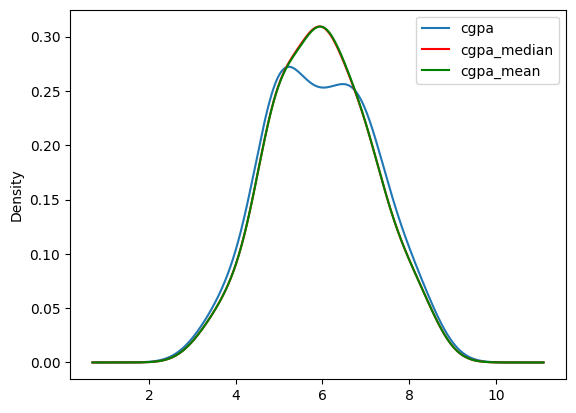

In [125]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['cgpa'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['cgpa_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['cgpa_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

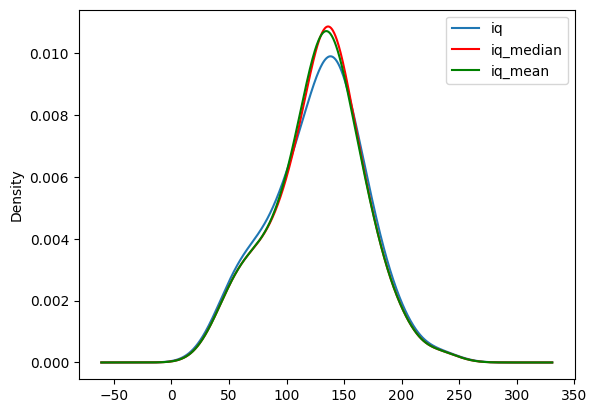

In [126]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['iq'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['iq_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['iq_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [127]:
X_train.cov()

,cgpa,iq,cgpa_median,cgpa_mean,iq_median,iq_mean
cgpa,1.477340,-9.173156,1.477340,1.477340,-8.808998,-8.676448
iq,-9.173156,1629.514595,-8.332189,-8.324700,1629.514595,1629.514595
cgpa_median,1.477340,-8.332189,1.327747,1.327736,-7.924304,-7.804835
cgpa_mean,1.477340,-8.324700,1.327736,1.327736,-7.916948,-7.797820
iq_median,-8.808998,1629.514595,-7.924304,-7.916948,1527.770728,1526.380759
iq_mean,-8.676448,1629.514595,-7.804835,-7.797820,1526.380759,1526.380759


In [128]:
X_train.corr()

,cgpa,iq,cgpa_median,cgpa_mean,iq_median,iq_mean
cgpa,1.000000,-0.185309,1.000000,1.000000,-0.184363,-0.181684
iq,-0.185309,1.000000,-0.177230,-0.177075,1.000000,1.000000
cgpa_median,1.000000,-0.177230,1.000000,0.999996,-0.175944,-0.173370
cgpa_mean,1.000000,-0.177075,0.999996,1.000000,-0.175781,-0.173215
iq_median,-0.184363,1.000000,-0.175944,-0.175781,1.000000,0.999545
iq_mean,-0.181684,1.000000,-0.173370,-0.173215,0.999545,1.000000


<Axes: >

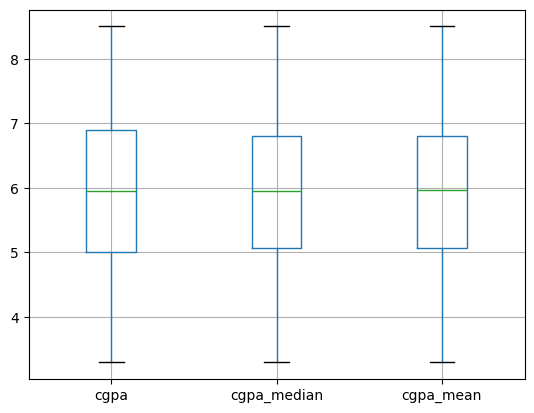

In [129]:
X_train[['cgpa', 'cgpa_median', 'cgpa_mean']].boxplot()

# Using Sklearn

In [130]:
from sklearn.impute import SimpleImputer
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [131]:
from sklearn.compose import ColumnTransformer

In [132]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['cgpa']),
    ('imputer2',imputer2,['iq'])
],remainder='passthrough')

In [133]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['cgpa']),
                                ('imputer2', SimpleImputer(), ['iq'])])

In [134]:
# X_train = trf.transform(X_train)
# X_test = trf.transform(X_test)   
#It would provide error cuz we dont have iq_mean
#iq_median,cgpa_mean and cgpa_median column here that we placed earlier

# Arbitrary Value Imputation

In [135]:
dfs = pd.read_csv("/kaggle/input/datasets/faizanhaider01/placement-modified/placement_modified.csv",usecols=['cgpa','iq','placement'])

In [136]:
dfs.sample(5)

,cgpa,iq,placement
72,7.3,116.0,1
67,5.0,NaN,0
21,7.1,151.0,1
15,5.1,176.0,0
36,5.7,140.0,0


In [137]:
X = dfs.drop(columns=['placement'])
y = dfs['placement']

In [138]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [139]:
X_train['cgpa_99'] = X_train['cgpa'].fillna(99)
X_train['cgpa_minus1'] = X_train['cgpa'].fillna(-1)

X_train['iq_999'] = X_train['iq'].fillna(199)
X_train['iq_minus1'] = X_train['iq'].fillna(-1)

In [146]:
X_train.sample(5)

,cgpa,iq,cgpa_99,cgpa_minus1,iq_999,iq_minus1
22,4.9,NaN,4.9,4.9,199.0,-1.0
80,4.9,196.0,4.9,4.9,196.0,196.0
70,NaN,127.0,99.0,-1.0,127.0,127.0
87,5.7,132.0,5.7,5.7,132.0,132.0
12,NaN,139.0,99.0,-1.0,139.0,139.0


In [142]:
print('Original Age variable variance: ', X_train['cgpa'].var())
print('cgpa Variance after 99 wala imputation: ', X_train['cgpa_99'].var())
print('cgpa Variance after -1 wala imputation: ', X_train['cgpa_minus1'].var())

print('Original iq variable variance: ', X_train['iq'].var())
print('iq Variance after 199 wala imputation: ', X_train['iq_999'].var())
print('iq Variance after -1 wala imputation: ', X_train['iq_minus1'].var())

Original Age variable variance:  1.4773395931142412
cgpa Variance after 99 wala imputation:  790.2504050632916
cgpa Variance after -1 wala imputation:  5.744075949367086
Original iq variable variance:  1629.5145945945942
iq Variance after 199 wala imputation:  1832.6101265822783
iq Variance after -1 wala imputation:  2500.964556962024


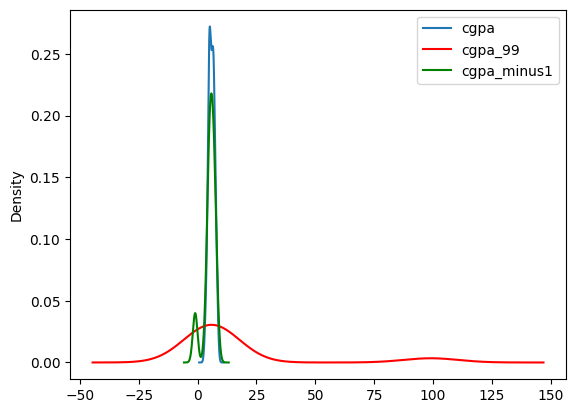

In [147]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['cgpa'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['cgpa_99'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['cgpa_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

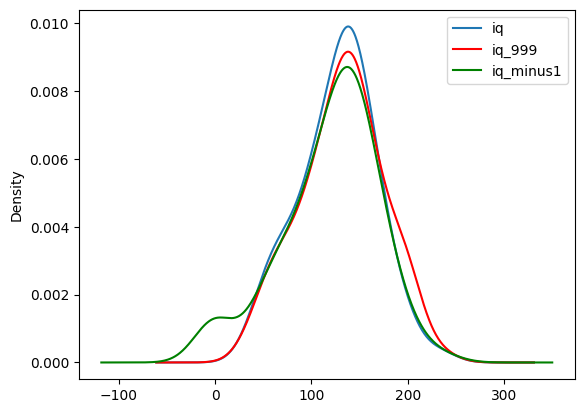

In [148]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['iq'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['iq_999'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['iq_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [ ]:
#USING SKLEARN
imputer1 = SimpleImputer(strategy='constant',fill_value=99)
imputer2 = SimpleImputer(strategy='constant',fill_value=199)